In [2]:
# ============================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Algorithms
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ============================================
# CELL 2: UPLOAD DATASET
# ============================================

from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat (1).csv


In [9]:
# ============================================
# CELL 3: LOAD DATASET
# ============================================

df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
# ============================================
# CELL 4: BASIC DATASET INFORMATION
# ============================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 395
Number of columns: 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  rea

In [11]:
# ============================================
# CELL 5: STATISTICAL SUMMARY
# ============================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,395,2,GP,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,395,2,F,208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,395.0,NaN,NaN,NaN,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
address,395,2,U,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,395,2,GT3,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,395,2,T,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,395.0,NaN,NaN,NaN,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,NaN,NaN,NaN,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
Mjob,395,5,other,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,395,5,other,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ============================================
# CELL 6: CHECK MISSING VALUES
# ============================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0


In [13]:
# ============================================
# CELL 7: CHECK DUPLICATES
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Remove duplicate records

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (395, 33)


In [15]:
# ============================================
# CELL 8: TARGET VARIABLE VALIDATION
# ============================================

print("G3 minimum:", df["G3"].min())
print("G3 maximum:", df["G3"].max())
print("G3 mean:", df["G3"].mean())
print("G3 median:", df["G3"].median())

G3 minimum: 0
G3 maximum: 20
G3 mean: 10.415189873417722
G3 median: 11.0


In [16]:
invalid_g3 = df[(df["G3"] < 0) | (df["G3"] > 20)]

print("Invalid G3 records:", len(invalid_g3))

Invalid G3 records: 0


In [17]:
# ============================================
# CELL 9: DATA CLEANING
# ============================================

# Remove duplicate records
df = df.drop_duplicates()

# Remove rows where target is missing
df = df.dropna(subset=["G3"])

# Make sure numerical columns are numeric
numeric_columns = [
    "age", "Medu", "Fedu", "traveltime",
    "studytime", "failures", "famrel",
    "freetime", "goout", "Dalc", "Walc",
    "health", "absences", "G1", "G2", "G3"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Data cleaning completed!")
print("Final shape:", df.shape)

Data cleaning completed!
Final shape: (395, 33)


In [18]:
# ============================================
# CELL 10: FEATURE ENGINEERING
# ============================================

# Academic performance indicator
df["academic_average"] = (df["G1"] + df["G2"]) / 2

# Total alcohol consumption indicator
df["alcohol_index"] = df["Dalc"] + df["Walc"]

# Social activity indicator
df["social_index"] = df["freetime"] + df["goout"]

# Support indicator
df["support_index"] = (
    (df["schoolsup"] == "yes").astype(int) +
    (df["famsup"] == "yes").astype(int)
)

print("New engineered features created!")

print("\nNew columns:")
print([
    "academic_average",
    "alcohol_index",
    "social_index",
    "support_index"
])

New engineered features created!

New columns:
['academic_average', 'alcohol_index', 'social_index', 'support_index']


In [19]:
# ============================================
# CELL 11: CHECK DATA AFTER WRANGLING
# ============================================

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Walc,health,absences,G1,G2,G3,academic_average,alcohol_index,social_index,support_index
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,3,6,5,6,6,5.5,2,7,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,3,4,5,5,6,5.0,2,6,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,3,10,7,8,10,7.5,5,5,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,5,2,15,14,15,14.5,2,4,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,5,4,6,10,10,8.0,3,5,1


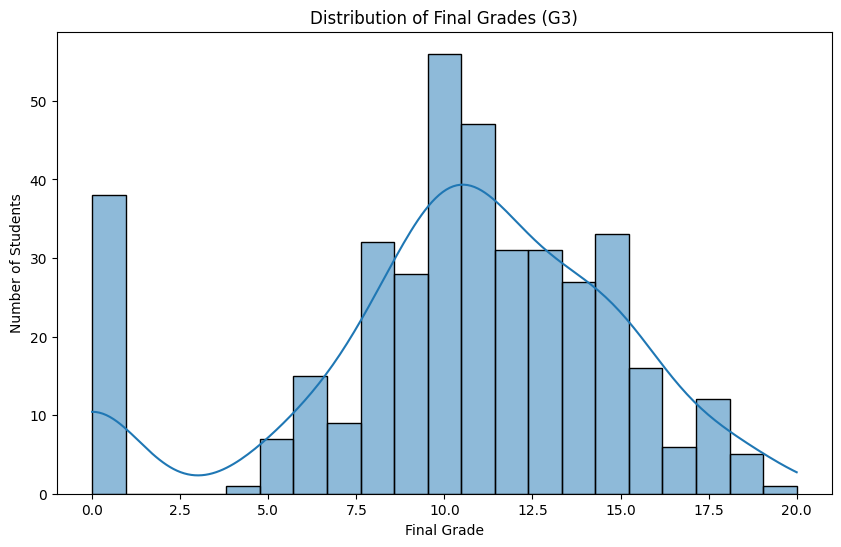

In [20]:
# ============================================
# CELL 12: FINAL GRADE DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["G3"],
    bins=21,
    kde=True
)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

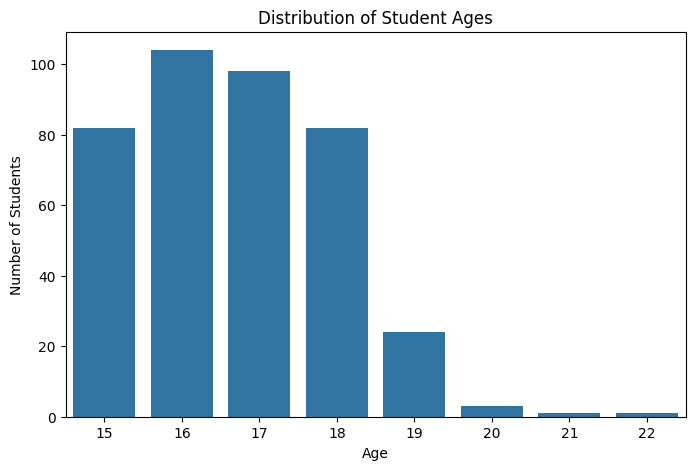

In [21]:
# ============================================
# CELL 13: AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x="age",
    data=df
)

plt.title("Distribution of Student Ages")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

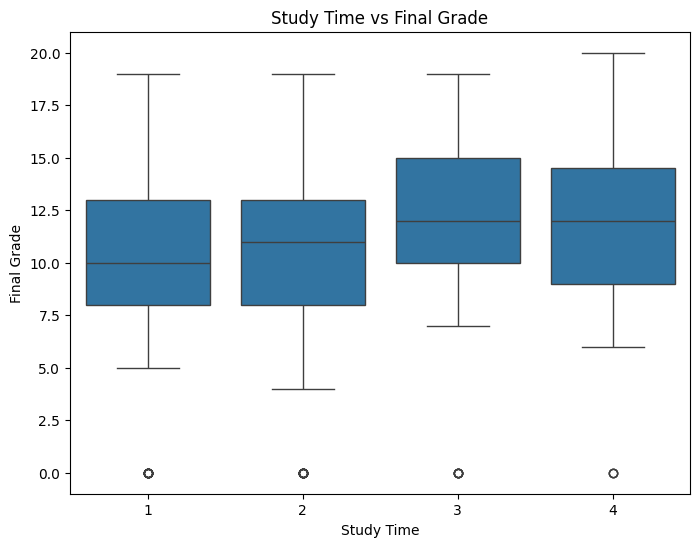

In [22]:
# ============================================
# CELL 14: STUDY TIME VS FINAL GRADE
# ============================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="studytime",
    y="G3",
    data=df
)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")

plt.show()

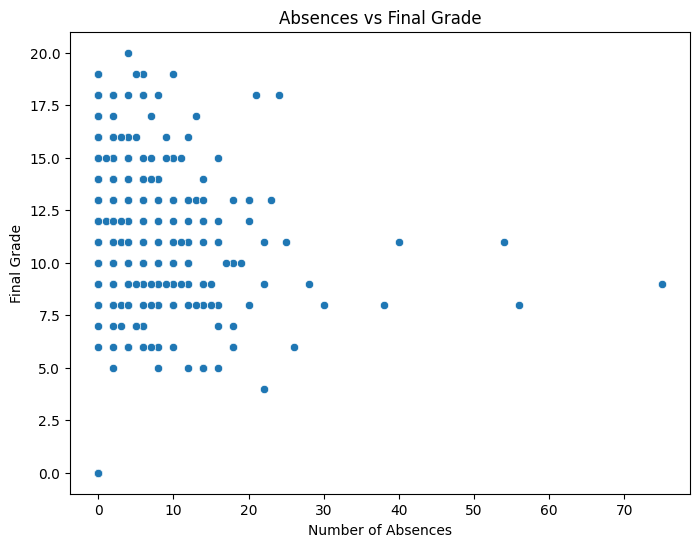

In [23]:
# ============================================
# CELL 15: ABSENCES VS FINAL GRADE
# ============================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="absences",
    y="G3",
    data=df
)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")

plt.show()

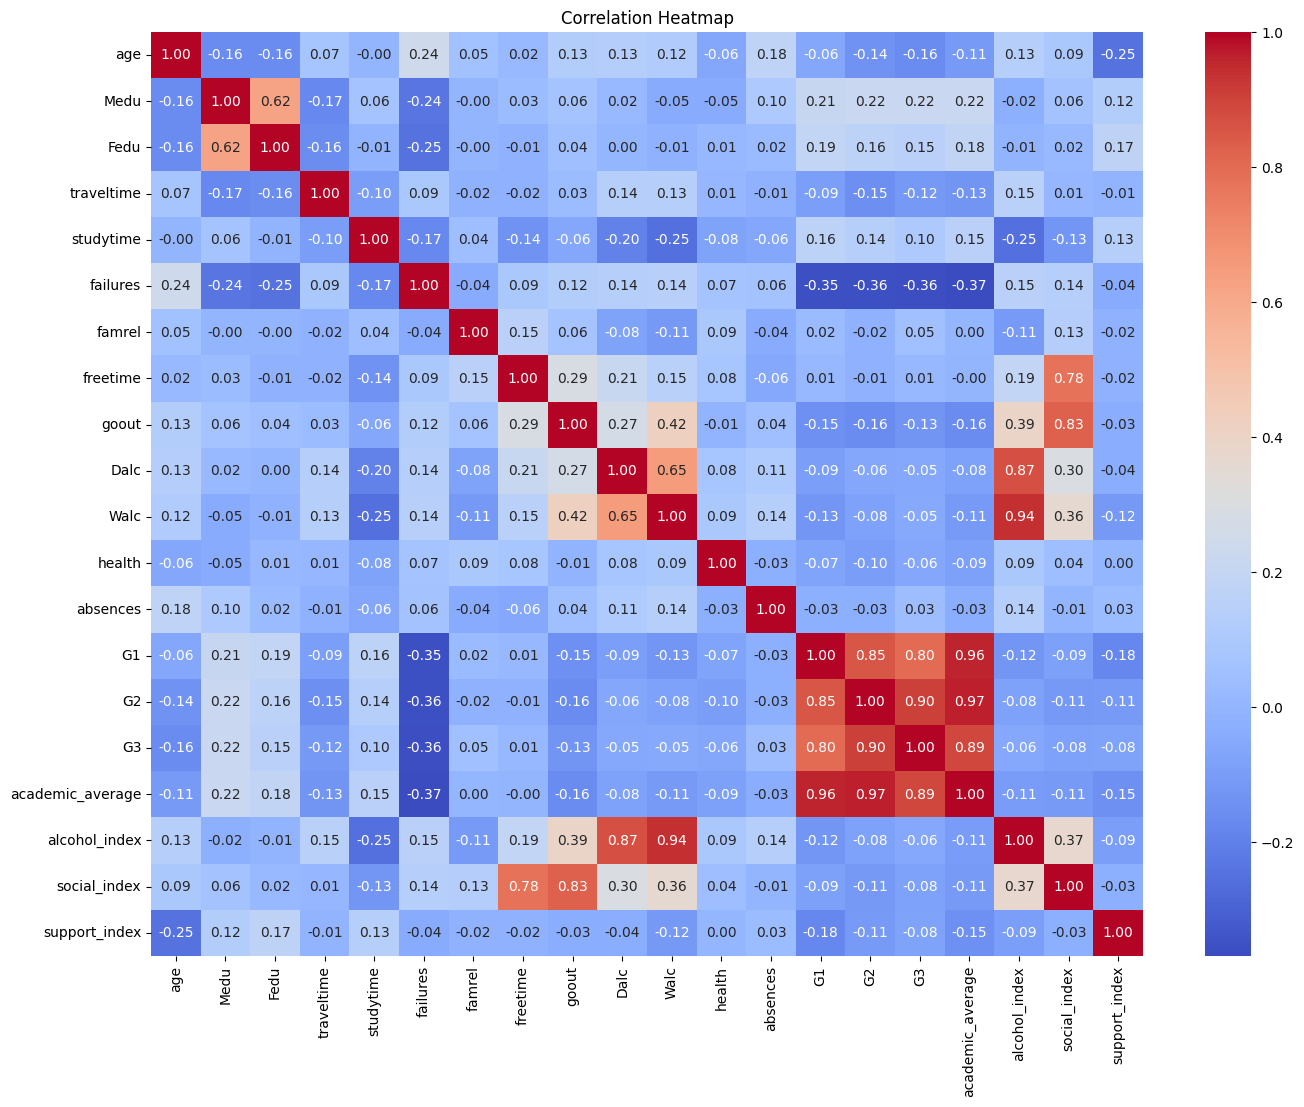

In [24]:
# ============================================
# CELL 16: CORRELATION HEATMAP
# ============================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 12))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

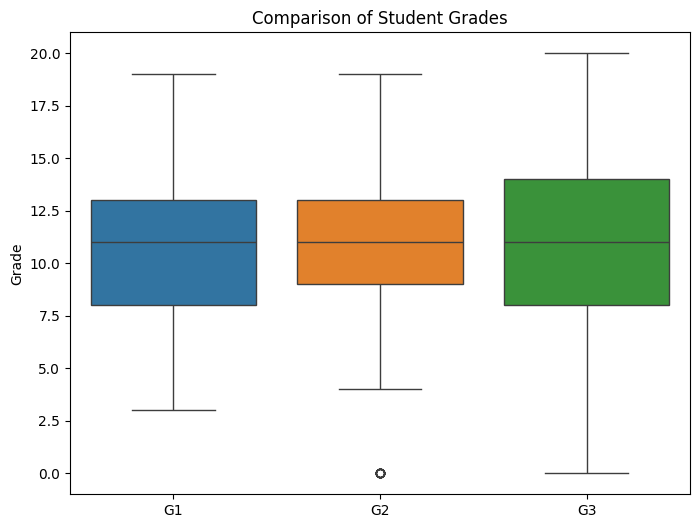

In [25]:
# ============================================
# CELL 17: G1, G2 AND G3
# ============================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df[["G1", "G2", "G3"]]
)

plt.title("Comparison of Student Grades")
plt.ylabel("Grade")

plt.show()

In [26]:
# ============================================
# CELL 18: DEFINE FEATURES AND TARGET
# ============================================

# Target
y = df["G3"]

# Remove target
X = df.drop(columns=["G3"])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (395, 36)
Target shape: (395,)

Features:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'academic_average', 'alcohol_index', 'social_index', 'support_index']


In [27]:
# ============================================
# CELL 19: TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 316
Testing records: 79


In [28]:
# ============================================
# CELL 20: IDENTIFY FEATURE TYPES
# ============================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'academic_average', 'alcohol_index', 'social_index', 'support_index']


In [29]:
# ============================================
# CELL 21: PREPROCESSING
# ============================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [30]:
# ============================================
# CELL 22: RANDOM FOREST MODEL
# ============================================

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [31]:
# ============================================
# CELL 23: RANDOM FOREST PREDICTION
# ============================================

rf_predictions = random_forest_pipeline.predict(X_test)

print("Random Forest predictions:")
print(rf_predictions[:10])

Random Forest predictions:
[ 8.17 11.87  6.61  9.49  8.53 12.78 18.65  7.43  6.55 13.3 ]


In [32]:
# ============================================
# CELL 24: SUPPORT VECTOR REGRESSION
# ============================================

svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            SVR()
        )
    ]
)

svr_pipeline.fit(
    X_train,
    y_train
)

print("SVR model trained successfully!")

SVR model trained successfully!


In [33]:
# ============================================
# CELL 25: SVR PREDICTION
# ============================================

svr_predictions = svr_pipeline.predict(X_test)

print("SVR predictions:")
print(svr_predictions[:10])

SVR predictions:
[ 8.24623009 11.91436452  4.29170856  9.08399414  9.62375854 11.97445306
 17.1436541   8.0341791   7.73864083 12.47266075]


In [34]:
# ============================================
# CELL 26: MODEL EVALUATION FUNCTION
# ============================================

def evaluate_model(y_true, predictions, model_name):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    print("\n", model_name)
    print("-" * 40)
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

    return mae, rmse, r2

In [35]:
rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_predictions,
    "Random Forest"
)

svr_mae, svr_rmse, svr_r2 = evaluate_model(
    y_test,
    svr_predictions,
    "Support Vector Regression"
)


 Random Forest
----------------------------------------
MAE : 1.1616
RMSE: 1.8679
R²  : 0.8298

 Support Vector Regression
----------------------------------------
MAE : 1.4502
RMSE: 2.324
R²  : 0.7366


In [36]:
# ============================================
# CELL 27: RANDOM FOREST HYPERPARAMETER TUNING
# ============================================

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Random Forest parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [37]:
# ============================================
# CELL 28: BEST RANDOM FOREST
# ============================================

best_rf = rf_grid.best_estimator_

best_rf_predictions = best_rf.predict(X_test)

tuned_rf_mae, tuned_rf_rmse, tuned_rf_r2 = evaluate_model(
    y_test,
    best_rf_predictions,
    "Tuned Random Forest"
)


 Tuned Random Forest
----------------------------------------
MAE : 1.3625
RMSE: 2.0681
R²  : 0.7914


In [38]:
# ============================================
# CELL 29: SVR HYPERPARAMETER TUNING
# ============================================

svr_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__epsilon": [0.01, 0.1, 0.2],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "linear"]
}

svr_grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=svr_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

svr_grid.fit(
    X_train,
    y_train
)

print("Best SVR parameters:")
print(svr_grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best SVR parameters:
{'model__C': 10, 'model__epsilon': 0.2, 'model__gamma': 'auto', 'model__kernel': 'rbf'}


In [39]:
# ============================================
# CELL 30: BEST SVR
# ============================================

best_svr = svr_grid.best_estimator_

best_svr_predictions = best_svr.predict(X_test)

tuned_svr_mae, tuned_svr_rmse, tuned_svr_r2 = evaluate_model(
    y_test,
    best_svr_predictions,
    "Tuned SVR"
)


 Tuned SVR
----------------------------------------
MAE : 1.5605
RMSE: 2.3844
R²  : 0.7227


In [40]:
# ============================================
# CELL 31: MODEL COMPARISON
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SVR"
    ],
    "MAE": [
        tuned_rf_mae,
        tuned_svr_mae
    ],
    "RMSE": [
        tuned_rf_rmse,
        tuned_svr_rmse
    ],
    "R2": [
        tuned_rf_r2,
        tuned_svr_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,1.362532,2.068067,0.791422
1,SVR,1.560486,2.384383,0.722737


In [41]:
# ============================================
# CELL 32: FIND BEST MODEL
# ============================================

# Lower MAE/RMSE is better.
# Higher R2 is better.

rf_score = (
    tuned_rf_r2
)

svr_score = (
    tuned_svr_r2
)

if rf_score > svr_score:
    best_model_name = "Random Forest"
    best_model = best_rf
else:
    best_model_name = "Support Vector Regression"
    best_model = best_svr

print("Best Performing Algorithm:")
print(best_model_name)

Best Performing Algorithm:
Random Forest


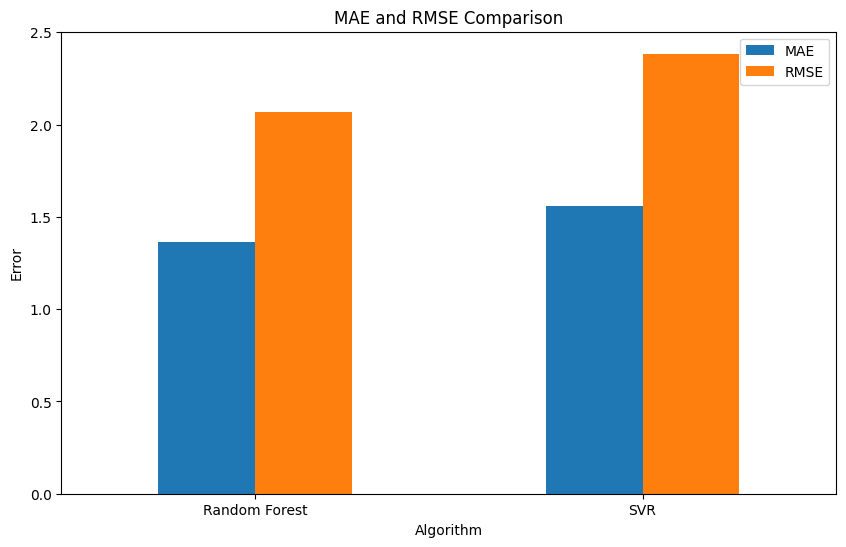

In [42]:
# ============================================
# CELL 33: MODEL COMPARISON CHART
# ============================================

comparison_plot = comparison.set_index("Model")

comparison_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("MAE and RMSE Comparison")
plt.ylabel("Error")
plt.xlabel("Algorithm")
plt.xticks(rotation=0)

plt.show()

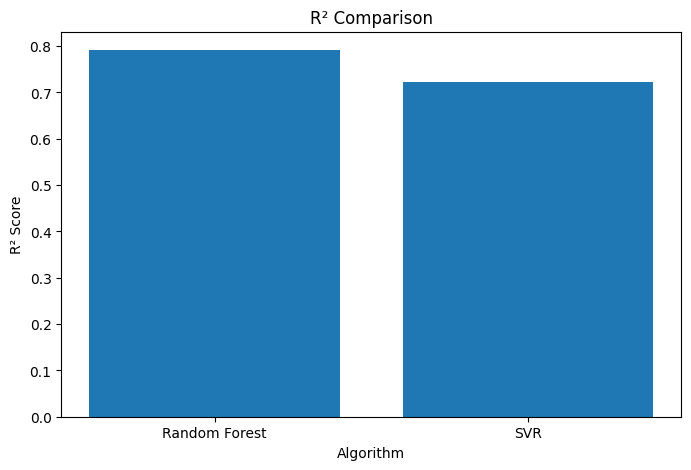

In [43]:
# ============================================
# CELL 34: R2 COMPARISON
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title("R² Comparison")
plt.xlabel("Algorithm")
plt.ylabel("R² Score")

plt.show()

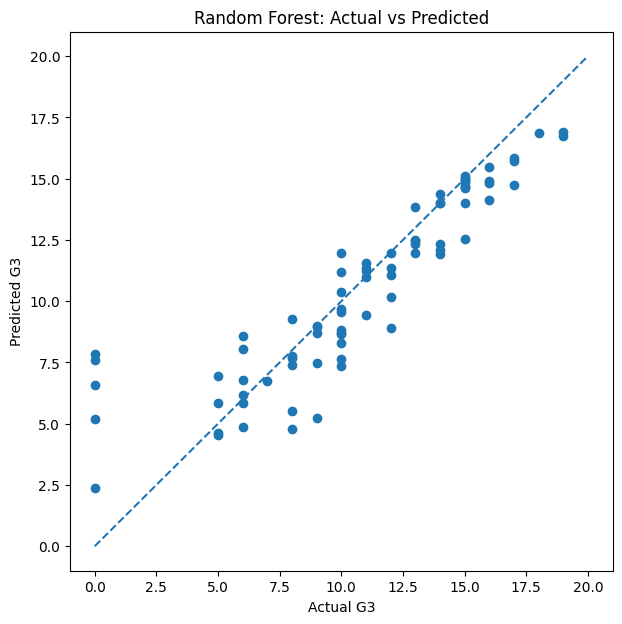

In [44]:
# ============================================
# CELL 35: RANDOM FOREST ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_rf_predictions
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Random Forest: Actual vs Predicted")

plt.plot(
    [0, 20],
    [0, 20],
    linestyle="--"
)

plt.show()

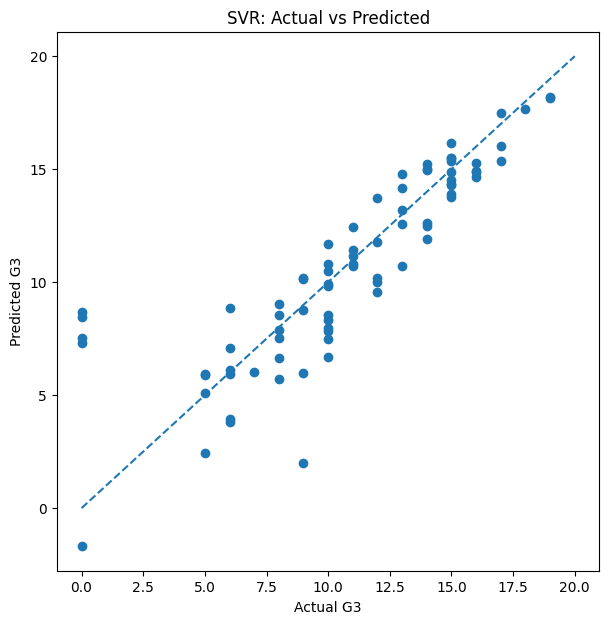

In [45]:
# ============================================
# CELL 36: SVR ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_svr_predictions
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("SVR: Actual vs Predicted")

plt.plot(
    [0, 20],
    [0, 20],
    linestyle="--"
)

plt.show()

In [46]:
# ============================================
# CELL 37: RANDOM FOREST FEATURE IMPORTANCE
# ============================================

rf_preprocessor = best_rf.named_steps["preprocessor"]
rf_model = best_rf.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
14,num__G2,0.266766
15,num__academic_average,0.219928
13,num__G1,0.127452
12,num__absences,0.057206
5,num__failures,0.024264
0,num__age,0.015134
8,num__goout,0.015055
11,num__health,0.012723
1,num__Medu,0.012431
17,num__social_index,0.011481


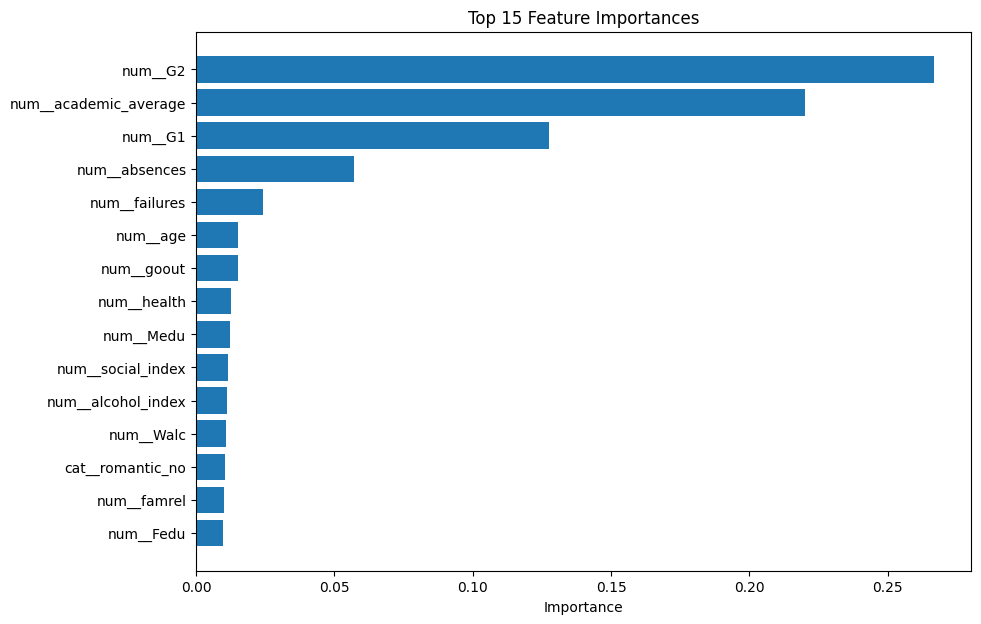

In [47]:
plt.figure(figsize=(10, 7))

top_features = feature_importance_df.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")

plt.show()

In [48]:
# ============================================
# CELL 38: FEATURE SELECTION
# ============================================

# Select numerical variables for statistical feature selection

X_numeric = df.select_dtypes(
    include=np.number
).drop(columns=["G3"])

y_numeric = df["G3"]

selector = SelectKBest(
    score_func=mutual_info_regression,
    k=min(10, X_numeric.shape[1])
)

X_selected = selector.fit_transform(
    X_numeric,
    y_numeric
)

selected_features = X_numeric.columns[
    selector.get_support()
]

print("Selected numerical features:")
print(selected_features.tolist())

Selected numerical features:
['failures', 'Walc', 'health', 'absences', 'G1', 'G2', 'academic_average', 'alcohol_index', 'social_index', 'support_index']


Data Augmentation

The dataset was examined to determine whether data augmentation was required. Since this is a small tabular regression dataset with a numerical target variable (G3), blindly duplicating records could introduce bias and overfitting.

Therefore, unnecessary duplication of records was avoided. Instead, the available training data was utilized through an appropriate train-test split and 5-fold cross-validation during hyperparameter tuning.

This approach maintains the integrity of the original observations while providing reliable model training and evaluation.

In [49]:
# ============================================
# CELL 40: SAVE TRAINED MODELS
# ============================================

joblib.dump(
    best_rf,
    "random_forest_model.pkl"
)

joblib.dump(
    best_svr,
    "svr_model.pkl"
)

joblib.dump(
    comparison,
    "model_comparison.pkl"
)

print("Models saved successfully!")

Models saved successfully!


In [55]:
# ============================================
# CELL 41: DOWNLOAD FILES
# ============================================

from google.colab import files

files.download("random_forest_model.pkl")
files.download("svr_model.pkl")
files.download("model_comparison.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>